In [2]:
with open("/content/TripA27.csv", "rb") as f:
    print(f.read(100))

b'Time [s];Velocity [km/h];Elevation [m];Throttle [%];Motor Torque [Nm];Longitudinal Acceleration [m/s'


In [3]:
import pandas as pd

df = pd.read_csv(
    "/content/TripA27.csv",
    sep=";",
    encoding="latin1"
)

print(df.head())

print("\nLast 5 Rows:")
print(df.tail())

print("\nShape of Dataset:")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nDataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nSummary Statistics:")
print(df.describe())



   Time [s]  Velocity [km/h]  Elevation [m]  Throttle [%]  Motor Torque [Nm]  \
0       0.0              0.0          521.0           0.0                0.0   
1       0.1              0.0          521.0           0.0                0.0   
2       0.2              0.0          521.0           0.0                0.0   
3       0.3              0.0          521.0           0.0                0.0   
4       0.4              0.0          521.0           0.0                0.0   

   Longitudinal Acceleration [m/s^2]  Regenerative Braking Signal   \
0                           -0.10800                           0.0   
1                           -0.09862                           0.0   
2                           -0.11609                           0.0   
3                           -0.12928                           0.0   
4                           -0.10800                           0.0   

   Battery Voltage [V]  Battery Current [A]  Battery Temperature [°C]  ...  \
0                388

In [4]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nSummary:")
print(df.describe())

Shape: (20005, 28)

Columns:
['Time [s]', 'Velocity [km/h]', 'Elevation [m]', 'Throttle [%]', 'Motor Torque [Nm]', 'Longitudinal Acceleration [m/s^2]', 'Regenerative Braking Signal ', 'Battery Voltage [V]', 'Battery Current [A]', 'Battery Temperature [°C]', 'max. Battery Temperature [°C]', 'SoC [%]', 'displayed SoC [%]', 'min. SoC [%]', 'max. SoC [%)', 'Heating Power CAN [kW]', 'Heating Power LIN [W]', 'Requested Heating Power [W]', 'AirCon Power [kW]', 'Heater Signal', 'Heater Voltage [V]', 'Heater Current [A]', 'Ambient Temperature [°C]', 'Coolant Temperature Heatercore [°C]', 'Requested Coolant Temperature [°C]', 'Coolant Temperature Inlet [°C]', 'Heat Exchanger Temperature [°C]', 'Cabin Temperature Sensor [°C]']

Missing Values:
Time [s]                               0
Velocity [km/h]                        0
Elevation [m]                          0
Throttle [%]                           0
Motor Torque [Nm]                      0
Longitudinal Acceleration [m/s^2]      0
Regenerativ

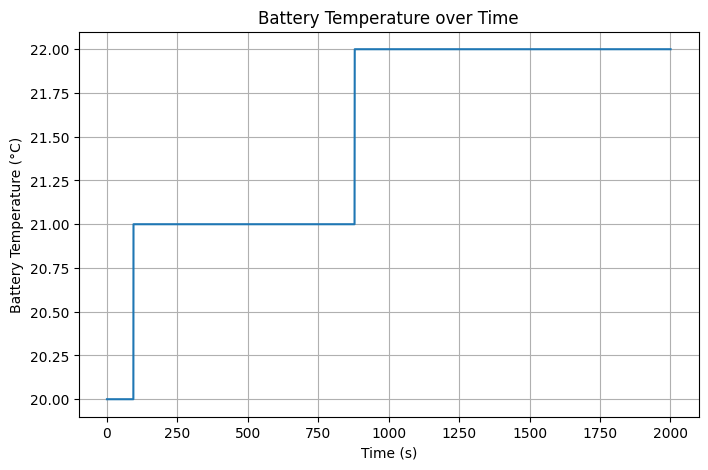

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(df["Time [s]"], df["Battery Temperature [°C]"])
plt.title("Battery Temperature over Time")
plt.xlabel("Time (s)")
plt.ylabel("Battery Temperature (°C)")
plt.grid(True)
plt.show()

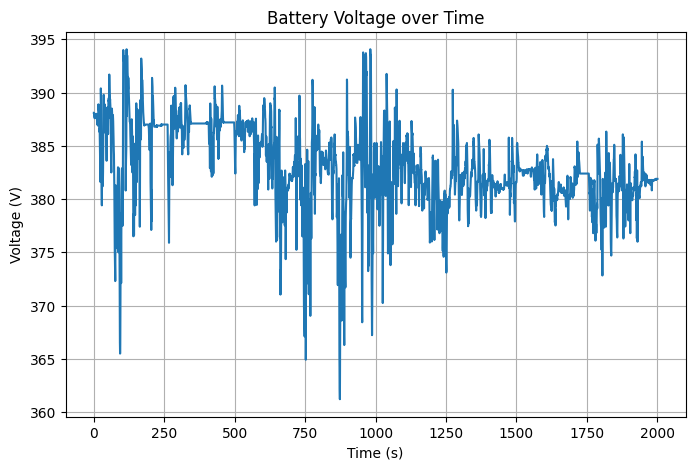

In [6]:
plt.figure(figsize=(8,5))
plt.plot(df["Time [s]"], df["Battery Voltage [V]"])
plt.title("Battery Voltage over Time")
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.grid(True)
plt.show()

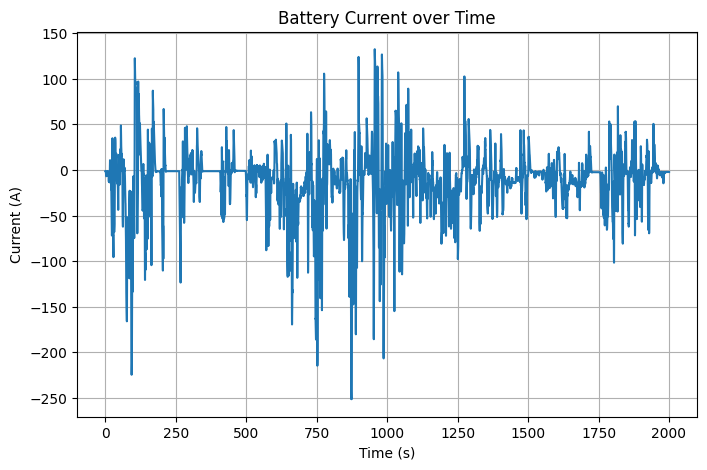

In [7]:
plt.figure(figsize=(8,5))
plt.plot(df["Time [s]"], df["Battery Current [A]"])
plt.title("Battery Current over Time")
plt.xlabel("Time (s)")
plt.ylabel("Current (A)")
plt.grid(True)
plt.show()

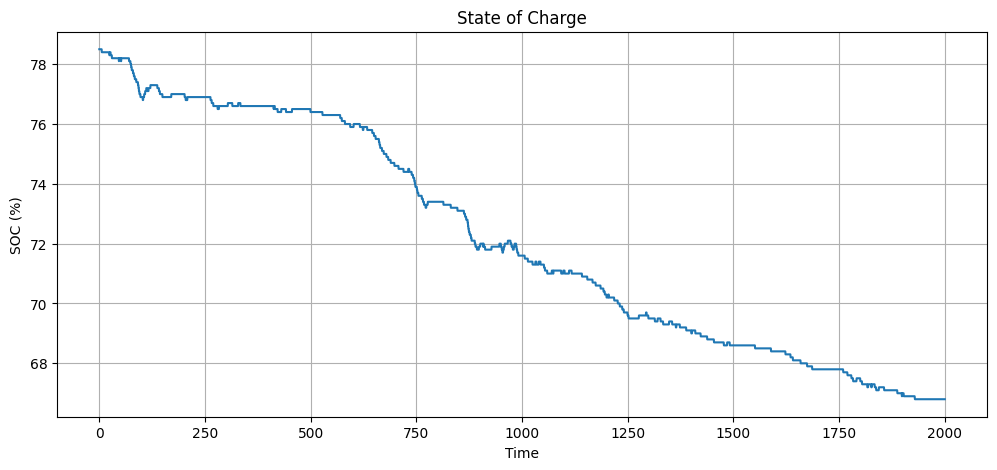

In [8]:
plt.figure(figsize=(12,5))

plt.plot(df["Time [s]"], df["SoC [%]"])

plt.title("State of Charge")
plt.xlabel("Time")
plt.ylabel("SOC (%)")
plt.grid(True)

plt.show()

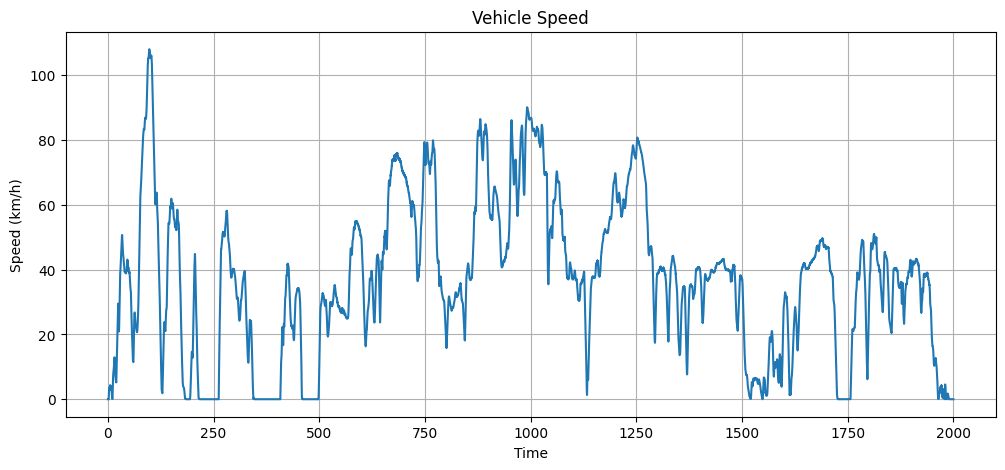

In [9]:
plt.figure(figsize=(12,5))

plt.plot(df["Time [s]"], df["Velocity [km/h]"])

plt.title("Vehicle Speed")
plt.xlabel("Time")
plt.ylabel("Speed (km/h)")
plt.grid(True)

plt.show()

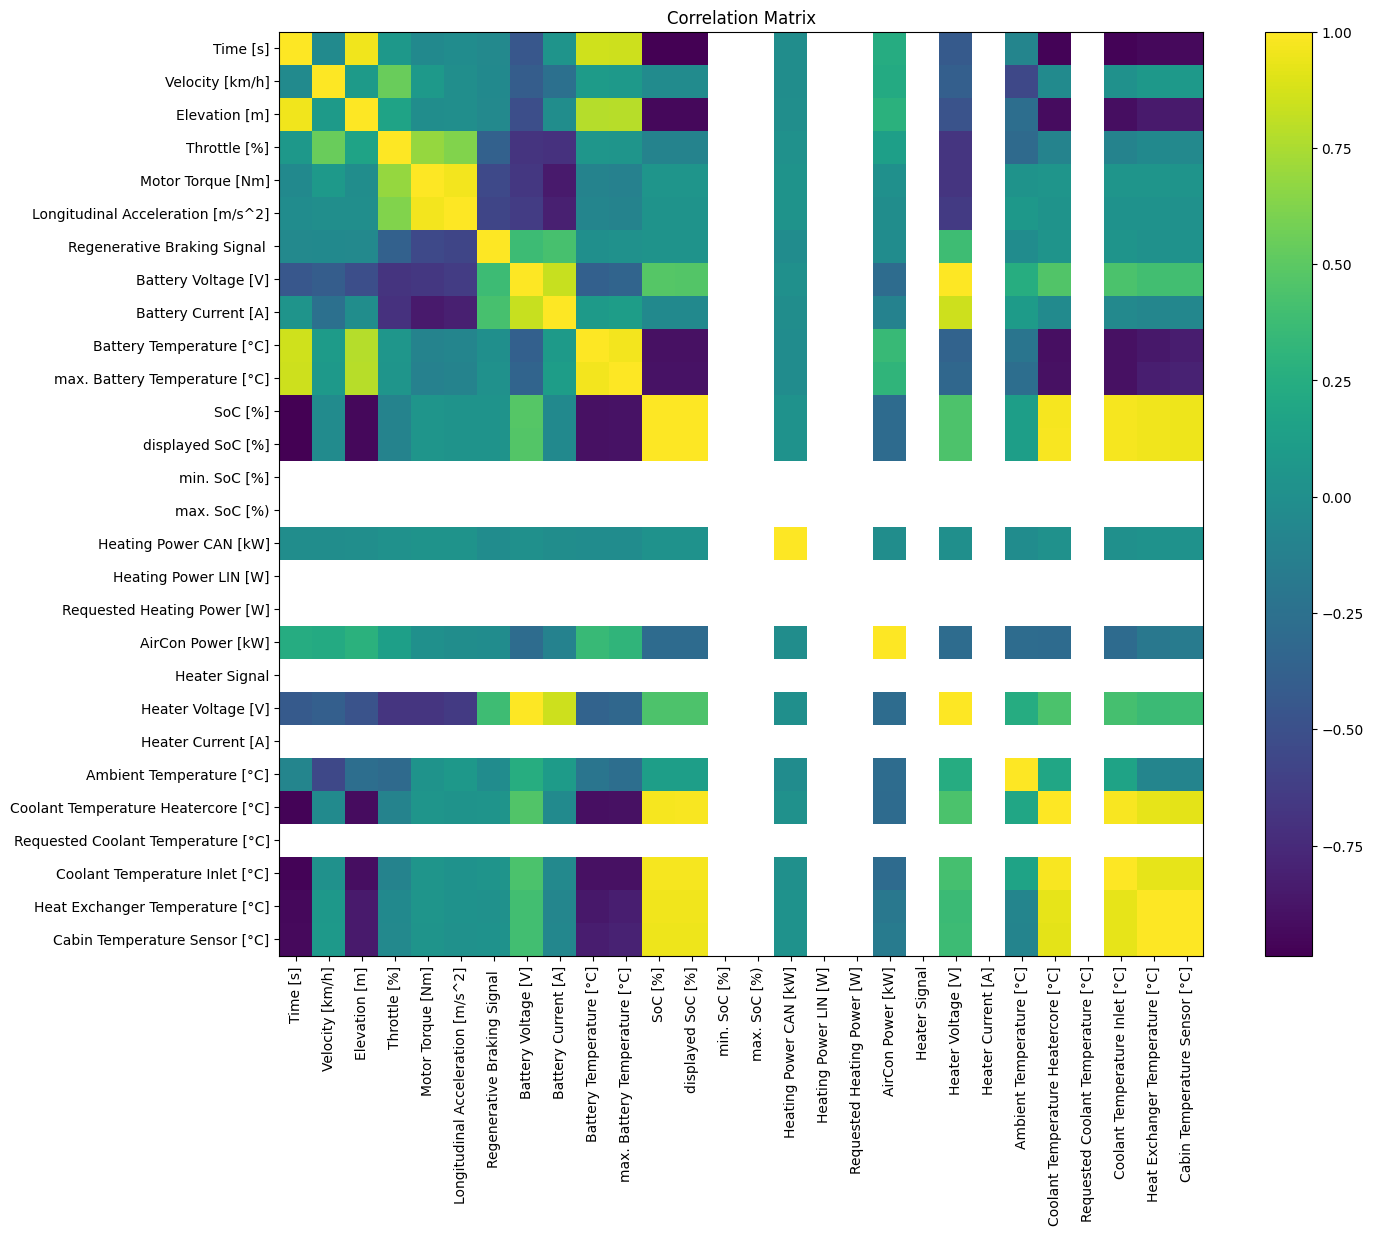

In [10]:
numeric_df = df.select_dtypes(include=["int64","float64"])

corr = numeric_df.corr()

plt.figure(figsize=(16,12))

plt.imshow(corr)

plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)

plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Matrix")

plt.show()

In [13]:
df.to_csv("clean_battery_dataset.csv", index=False)

print("Dataset Saved Successfully")

Dataset Saved Successfully


LOAD CLEAN DATASET

In [14]:
import pandas as pd

df = pd.read_csv("/content/clean_battery_dataset.csv")

print(df.head())

   Time [s]  Velocity [km/h]  Elevation [m]  Throttle [%]  Motor Torque [Nm]  \
0       0.0              0.0          521.0           0.0                0.0   
1       0.1              0.0          521.0           0.0                0.0   
2       0.2              0.0          521.0           0.0                0.0   
3       0.3              0.0          521.0           0.0                0.0   
4       0.4              0.0          521.0           0.0                0.0   

   Longitudinal Acceleration [m/s^2]  Regenerative Braking Signal   \
0                           -0.10800                           0.0   
1                           -0.09862                           0.0   
2                           -0.11609                           0.0   
3                           -0.12928                           0.0   
4                           -0.10800                           0.0   

   Battery Voltage [V]  Battery Current [A]  Battery Temperature [°C]  ...  \
0                388

In [15]:
features = [
    "Battery Voltage [V]",
    "Battery Current [A]",
    "SoC [%]",
    "Velocity [km/h]",
    "Motor Torque [Nm]",
    "Ambient Temperature [°C]",
    "AirCon Power [kW]",
    "Coolant Temperature Inlet [°C]",
    "Heat Exchanger Temperature [°C]"
]

target = "Battery Temperature [°C]"

X = df[features]
y = df[target]

print(X.head())
print(y.head())

   Battery Voltage [V]  Battery Current [A]  SoC [%]  Velocity [km/h]  \
0                388.1             -1.30000     78.5              0.0   
1                388.1             -1.30000     78.5              0.0   
2                388.1             -1.29807     78.5              0.0   
3                388.1             -1.24808     78.5              0.0   
4                388.1             -1.20191     78.5              0.0   

   Motor Torque [Nm]  Ambient Temperature [°C]  AirCon Power [kW]  \
0                0.0                      25.5                0.0   
1                0.0                      25.5                0.0   
2                0.0                      25.5                0.0   
3                0.0                      25.5                0.0   
4                0.0                      25.5                0.0   

   Coolant Temperature Inlet [°C]  Heat Exchanger Temperature [°C]  
0                            35.0                             26.0  
1       

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples :", X_train.shape)
print("Testing samples :", X_test.shape)

Training samples : (16004, 9)
Testing samples : (4001, 9)


In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)


In [18]:
import joblib

joblib.dump(scaler, "scaler.pkl")

pd.DataFrame(X_train_scaled, columns=features).to_csv("X_train.csv", index=False)
pd.DataFrame(X_test_scaled, columns=features).to_csv("X_test.csv", index=False)

y_train.to_csv("y_train.csv", index=False)
y_test.to_csv("y_test.csv", index=False)

print("Preprocessed data saved successfully!")

Preprocessed data saved successfully!


In [19]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

In [20]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    )
}

In [21]:
results = []

for name, model in models.items():

    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)

    mae = mean_absolute_error(y_test, y_pred)

    mse = mean_squared_error(y_test, y_pred)

    rmse = np.sqrt(mse)

    r2 = r2_score(y_test, y_pred)

    results.append([name, mae, rmse, r2])

    print("="*50)
    print(name)
    print("MAE :", mae)
    print("RMSE:", rmse)
    print("R² :", r2)

Linear Regression
MAE : 0.1608169320515729
RMSE: 0.2197259270546122
R² : 0.854222676921156
Decision Tree
MAE : 0.0003788152961759554
RMSE: 0.016943252572869886
R² : 0.9991331959540201
Random Forest
MAE : 0.0004255986003499203
RMSE: 0.016807571879321213
R² : 0.9991470230125409
Gradient Boosting
MAE : 0.001153808338926002
RMSE: 0.013558904198634928
R² : 0.9994448932038702


In [24]:
best_model = models["Gradient Boosting"]

y_pred = best_model.predict(X_test_scaled)

In [25]:
import joblib

joblib.dump(best_model, "battery_temperature_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(features, "features.pkl")

print("Files Saved Successfully!")

Files Saved Successfully!


In [26]:
sample = X_test_scaled[0].reshape(1, -1)

prediction = best_model.predict(sample)

print("Predicted :", prediction[0])
print("Actual :", y_test.iloc[0])

Predicted : 21.999684924994813
Actual : 22.0


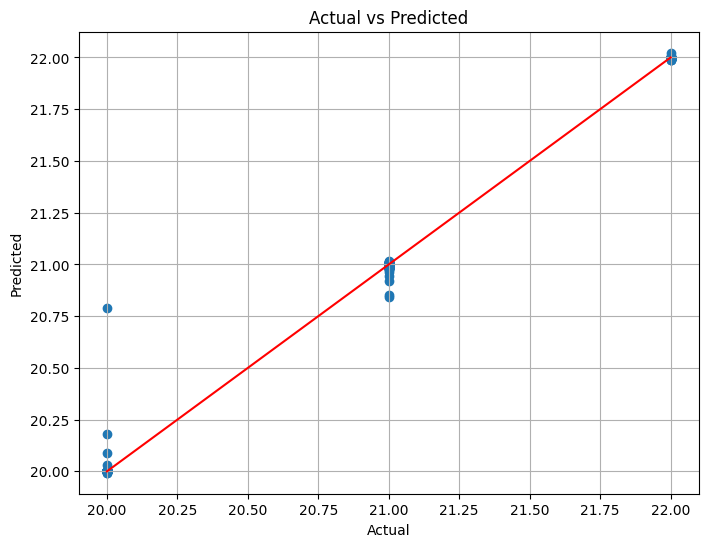

In [27]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red'
)

plt.xlabel("Actual")

plt.ylabel("Predicted")

plt.title("Actual vs Predicted")

plt.grid(True)

plt.show()

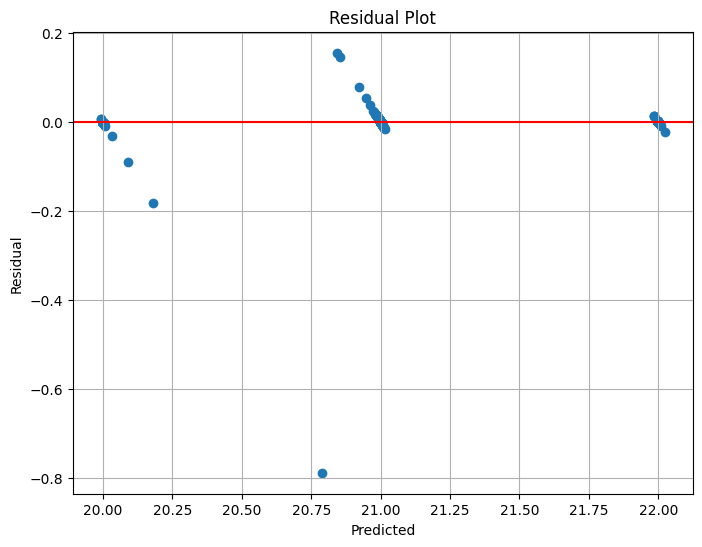

In [28]:
residual = y_test - y_pred

plt.figure(figsize=(8,6))

plt.scatter(y_pred, residual)

plt.axhline(0, color='red')

plt.xlabel("Predicted")

plt.ylabel("Residual")

plt.title("Residual Plot")

plt.grid(True)

plt.show()

In [29]:
importance = pd.DataFrame({
    "Feature": features,
    "Importance": best_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

                           Feature  Importance
2                          SoC [%]    0.997296
1              Battery Current [A]    0.001233
3                  Velocity [km/h]    0.001215
0              Battery Voltage [V]    0.000126
5         Ambient Temperature [°C]    0.000067
4                Motor Torque [Nm]    0.000037
8  Heat Exchanger Temperature [°C]    0.000017
7   Coolant Temperature Inlet [°C]    0.000009
6                AirCon Power [kW]    0.000001


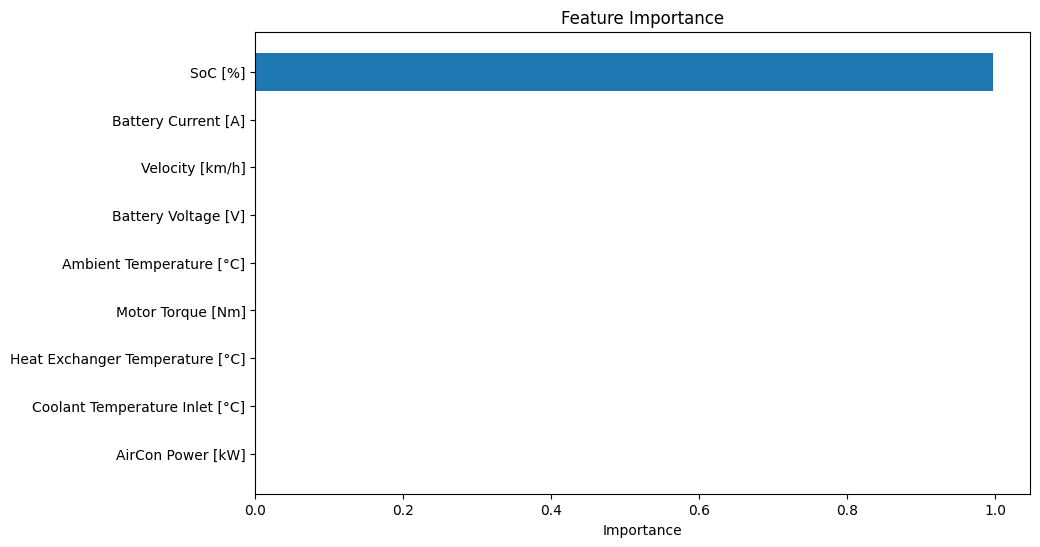

In [30]:
plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.xlabel("Importance")

plt.title("Feature Importance")

plt.gca().invert_yaxis()

plt.show()